## 6.1.1 统一训练环境与随机性控制

本节在正式训练开始前，对项目运行路径、软件环境、计算设备和随机性控制策略进行统一配置。

主要任务包括：

1. 自动定位课设项目根目录；
2. 建立本步骤独立结果目录；
3. 固定 Python、NumPy、PyTorch 和 DataLoader 随机种子；
4. 配置 PyTorch 确定性计算模式；
5. 记录 Python、PyTorch、Torchvision、CUDA 和 cuDNN 等环境信息；
6. 检查 CPU、GPU 和其他加速设备状态；
7. 验证相同随机种子下随机序列与模型前向传播结果的一致性；
8. 保存后续训练阶段可复用的统一运行配置。

本节只完成训练环境配置与完整性检查，不执行模型训练。

In [1]:
# ==========================================
# 6.1.1 基础导入、项目路径与输出目录
# ==========================================

# 必须在 NumPy、PyTorch、Matplotlib 等库导入之前设置
import os

# 临时允许重复加载 Intel OpenMP 运行库
# 用于解决 Windows + Conda 环境下的 libiomp5md.dll 冲突
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 限制各数值计算后端的线程数量，减少运行库冲突
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# PyTorch 确定性计算配置
os.environ.setdefault(
    "CUBLAS_WORKSPACE_CONFIG",
    ":4096:8"
)

os.environ.setdefault(
    "PYTHONHASHSEED",
    "42"
)


# 以下才开始导入其他库
import sys
import json
import random
import platform
import warnings
import importlib.metadata as importlib_metadata

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

from matplotlib.patches import (
    FancyBboxPatch,
    Rectangle
)

import torch
import torch.nn as nn
import torchvision

from IPython.display import display


# 进一步限制 PyTorch CPU 线程
torch.set_num_threads(1)

try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    # 若当前内核已经启动过并行任务，可能无法再次修改
    pass


warnings.filterwarnings(
    "default"
)


# ------------------------------
# 自动定位项目根目录
# ------------------------------
def find_project_root(
    start_path=None
):
    """
    从当前工作目录开始向上搜索项目根目录。

    项目根目录应同时包含：
    1. EuroSAT_RGB
    2. models
    3. notebooks
    """

    current_path = (
        Path.cwd()
        if start_path is None
        else Path(start_path).resolve()
    )

    candidate_paths = [
        current_path,
        *current_path.parents
    ]

    for candidate_path in candidate_paths:

        required_paths = [
            candidate_path / "EuroSAT_RGB",
            candidate_path / "models",
            candidate_path / "notebooks"
        ]

        if all(
            path.exists()
            for path in required_paths
        ):
            return candidate_path

    raise FileNotFoundError(
        "未能自动定位项目根目录。\n"
        "请确认项目根目录同时包含："
        "EuroSAT_RGB、models 和 notebooks 文件夹。"
    )


PROJECT_ROOT = find_project_root()


# ------------------------------
# 项目固定目录
# ------------------------------
DATA_DIR = (
    PROJECT_ROOT
    / "EuroSAT_RGB"
)

MODELS_DIR = (
    PROJECT_ROOT
    / "models"
)

NOTEBOOKS_DIR = (
    PROJECT_ROOT
    / "notebooks"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


# ------------------------------
# 本步骤独立输出目录
# ------------------------------
STEP_OUTPUT_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.1_统一训练环境与随机性控制"
)

STEP_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------
# Matplotlib中文字体设置
# ------------------------------
font_candidates = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Source Han Sans CN",
    "Arial Unicode MS"
]

available_fonts = {
    font.name
    for font in font_manager.fontManager.ttflist
}

selected_font = next(
    (
        font_name
        for font_name in font_candidates
        if font_name in available_fonts
    ),
    None
)

if selected_font is not None:
    plt.rcParams[
        "font.sans-serif"
    ] = [
        selected_font
    ]

plt.rcParams[
    "axes.unicode_minus"
] = False

plt.rcParams[
    "figure.dpi"
] = 120

plt.rcParams[
    "savefig.dpi"
] = 300

plt.rcParams[
    "axes.titleweight"
] = "bold"

plt.rcParams[
    "axes.labelweight"
] = "bold"


# ------------------------------
# Pandas显示设置
# ------------------------------
pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    160
)

pd.set_option(
    "display.max_colwidth",
    100
)


# ------------------------------
# 输出目录检查
# ------------------------------
directory_check_df = pd.DataFrame({
    "目录项目": [
        "项目根目录",
        "EuroSAT数据目录",
        "模型目录",
        "Notebook目录",
        "总结果目录",
        "本步骤结果目录"
    ],
    "绝对路径": [
        str(PROJECT_ROOT),
        str(DATA_DIR),
        str(MODELS_DIR),
        str(NOTEBOOKS_DIR),
        str(RESULTS_DIR),
        str(STEP_OUTPUT_DIR)
    ],
    "是否存在": [
        PROJECT_ROOT.exists(),
        DATA_DIR.exists(),
        MODELS_DIR.exists(),
        NOTEBOOKS_DIR.exists(),
        RESULTS_DIR.exists(),
        STEP_OUTPUT_DIR.exists()
    ]
})


print(
    "项目目录自动定位完成。"
)

print(
    f"项目根目录：{PROJECT_ROOT}"
)

print(
    f"本步骤输出目录：{STEP_OUTPUT_DIR}"
)

if selected_font is not None:
    print(
        f"当前绘图中文字体：{selected_font}"
    )
else:
    print(
        "警告：未找到预设中文字体，"
        "绘图时可能出现中文显示异常。"
    )


display(
    directory_check_df
)


assert directory_check_df[
    "是否存在"
].all(), (
    "部分项目目录不存在，请检查目录结构。"
)

项目目录自动定位完成。
项目根目录：d:\qy\junior\深度学习\课设
本步骤输出目录：d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制
当前绘图中文字体：Microsoft YaHei


,目录项目,绝对路径,是否存在
0,项目根目录,d:\qy\junior\深度学习\课设,True
1,EuroSAT数据目录,d:\qy\junior\深度学习\课设\EuroSAT_RGB,True
2,模型目录,d:\qy\junior\深度学习\课设\models,True
3,Notebook目录,d:\qy\junior\深度学习\课设\notebooks,True
4,总结果目录,d:\qy\junior\深度学习\课设\results,True
5,本步骤结果目录,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制,True


In [2]:
# ==========================================
# 6.1.1 统一随机种子和确定性配置
# ==========================================

GLOBAL_SEED = 42

DETERMINISTIC_MODE = True

DETERMINISTIC_WARN_ONLY = True


def seed_everything(
    seed=GLOBAL_SEED,
    deterministic=True,
    warn_only=True
):
    """
    固定当前实验使用的主要随机数生成器。

    包括：
    1. Python random
    2. NumPy
    3. PyTorch CPU
    4. PyTorch CUDA
    5. cuDNN确定性配置
    """

    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed(
            seed
        )

        torch.cuda.manual_seed_all(
            seed
        )

    if hasattr(
        torch.backends,
        "cudnn"
    ):

        torch.backends.cudnn.deterministic = (
            deterministic
        )

        torch.backends.cudnn.benchmark = (
            not deterministic
        )

    if (
        deterministic
        and hasattr(
            torch,
            "use_deterministic_algorithms"
        )
    ):

        try:
            torch.use_deterministic_algorithms(
                True,
                warn_only=warn_only
            )

        except TypeError:
            # 兼容较旧版本PyTorch
            torch.use_deterministic_algorithms(
                True
            )


def seed_worker(
    worker_id
):
    """
    供后续DataLoader的worker_init_fn使用。
    """

    worker_seed = (
        torch.initial_seed()
        % (2 ** 32)
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


def build_torch_generator(
    seed=GLOBAL_SEED
):
    """
    构建供DataLoader使用的固定随机生成器。
    """

    generator = (
        torch.Generator()
    )

    generator.manual_seed(
        seed
    )

    return generator


# 应用统一随机配置
seed_everything(
    seed=GLOBAL_SEED,
    deterministic=DETERMINISTIC_MODE,
    warn_only=DETERMINISTIC_WARN_ONLY
)


# 后续DataLoader可以直接使用
DATALOADER_GENERATOR = (
    build_torch_generator(
        GLOBAL_SEED
    )
)


# ------------------------------
# 获取确定性配置状态
# ------------------------------
if hasattr(
    torch,
    "are_deterministic_algorithms_enabled"
):
    deterministic_algorithms_enabled = (
        torch.are_deterministic_algorithms_enabled()
    )
else:
    deterministic_algorithms_enabled = (
        DETERMINISTIC_MODE
    )


cudnn_deterministic = (
    bool(
        torch.backends.cudnn.deterministic
    )
    if hasattr(
        torch.backends,
        "cudnn"
    )
    else False
)

cudnn_benchmark = (
    bool(
        torch.backends.cudnn.benchmark
    )
    if hasattr(
        torch.backends,
        "cudnn"
    )
    else False
)


seed_config = {
    "全局随机种子": GLOBAL_SEED,
    "Python随机种子": GLOBAL_SEED,
    "NumPy随机种子": GLOBAL_SEED,
    "PyTorch_CPU随机种子": GLOBAL_SEED,
    "PyTorch_CUDA随机种子": (
        GLOBAL_SEED
        if torch.cuda.is_available()
        else "当前环境未启用CUDA"
    ),
    "确定性模式": DETERMINISTIC_MODE,
    "确定性算法警告模式": (
        DETERMINISTIC_WARN_ONLY
    ),
    "确定性算法是否启用": (
        deterministic_algorithms_enabled
    ),
    "cuDNN_deterministic": (
        cudnn_deterministic
    ),
    "cuDNN_benchmark": (
        cudnn_benchmark
    ),
    "CUBLAS_WORKSPACE_CONFIG": (
        os.environ.get(
            "CUBLAS_WORKSPACE_CONFIG",
            "未设置"
        )
    ),
    "DataLoader_worker_init_fn": (
        "seed_worker"
    ),
    "DataLoader_generator_seed": (
        GLOBAL_SEED
    )
}


seed_config_df = pd.DataFrame({
    "配置项目": list(
        seed_config.keys()
    ),
    "配置值": list(
        seed_config.values()
    )
})


seed_config_path = (
    STEP_OUTPUT_DIR
    / "01_随机性控制配置.json"
)

with open(
    seed_config_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        seed_config,
        file,
        ensure_ascii=False,
        indent=4
    )


print(
    "随机种子与确定性计算配置完成。"
)

display(
    seed_config_df
)

print(
    f"\n配置文件已保存："
    f"{seed_config_path.name}"
)

随机种子与确定性计算配置完成。


,配置项目,配置值
0,全局随机种子,42
1,Python随机种子,42
2,NumPy随机种子,42
3,PyTorch_CPU随机种子,42
4,PyTorch_CUDA随机种子,当前环境未启用CUDA
5,确定性模式,True
6,确定性算法警告模式,True
7,确定性算法是否启用,True
8,cuDNN_deterministic,True
9,cuDNN_benchmark,False



配置文件已保存：01_随机性控制配置.json


In [3]:
# ==========================================
# 6.1.1 运行环境与软件版本记录
# ==========================================

def get_package_version(
    package_name
):
    """
    安全读取Python软件包版本。
    """

    try:
        return importlib_metadata.version(
            package_name
        )

    except importlib_metadata.PackageNotFoundError:
        return "未安装"

    except Exception as error:
        return (
            f"读取失败："
            f"{type(error).__name__}"
        )


def safe_get_interop_threads():
    """
    安全读取PyTorch跨算子线程数。
    """

    try:
        return torch.get_num_interop_threads()

    except Exception:
        return "当前版本无法读取"


cuda_build_version = (
    torch.version.cuda
    if torch.version.cuda is not None
    else "未使用CUDA构建"
)

cudnn_version = (
    torch.backends.cudnn.version()
    if (
        hasattr(
            torch.backends,
            "cudnn"
        )
        and torch.backends.cudnn.is_available()
    )
    else "当前环境不可用"
)


environment_records = [
    {
        "环境项目": "记录时间",
        "环境信息": datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )
    },
    {
        "环境项目": "操作系统",
        "环境信息": platform.platform()
    },
    {
        "环境项目": "系统名称",
        "环境信息": platform.system()
    },
    {
        "环境项目": "系统版本",
        "环境信息": platform.version()
    },
    {
        "环境项目": "系统架构",
        "环境信息": platform.machine()
    },
    {
        "环境项目": "处理器信息",
        "环境信息": (
            platform.processor()
            or "系统未返回处理器名称"
        )
    },
    {
        "环境项目": "Python版本",
        "环境信息": platform.python_version()
    },
    {
        "环境项目": "Python解释器",
        "环境信息": sys.executable
    },
    {
        "环境项目": "Conda环境",
        "环境信息": os.environ.get(
            "CONDA_DEFAULT_ENV",
            "非Conda环境或无法读取"
        )
    },
    {
        "环境项目": "PyTorch版本",
        "环境信息": torch.__version__
    },
    {
        "环境项目": "Torchvision版本",
        "环境信息": torchvision.__version__
    },
    {
        "环境项目": "NumPy版本",
        "环境信息": np.__version__
    },
    {
        "环境项目": "Pandas版本",
        "环境信息": pd.__version__
    },
    {
        "环境项目": "Matplotlib版本",
        "环境信息": matplotlib.__version__
    },
    {
        "环境项目": "Pillow版本",
        "环境信息": get_package_version(
            "pillow"
        )
    },
    {
        "环境项目": "Scikit-learn版本",
        "环境信息": get_package_version(
            "scikit-learn"
        )
    },
    {
        "环境项目": "IPython版本",
        "环境信息": get_package_version(
            "ipython"
        )
    },
    {
        "环境项目": "ipykernel版本",
        "环境信息": get_package_version(
            "ipykernel"
        )
    },
    {
        "环境项目": "PyTorch CUDA构建版本",
        "环境信息": cuda_build_version
    },
    {
        "环境项目": "cuDNN版本",
        "环境信息": cudnn_version
    },
    {
        "环境项目": "PyTorch CPU线程数",
        "环境信息": torch.get_num_threads()
    },
    {
        "环境项目": "PyTorch跨算子线程数",
        "环境信息": safe_get_interop_threads()
    },
    {
        "环境项目": "逻辑CPU核心数",
        "环境信息": (
            os.cpu_count()
            if os.cpu_count() is not None
            else "无法读取"
        )
    },
    {
        "环境项目": "当前工作目录",
        "环境信息": str(
            Path.cwd()
        )
    },
    {
        "环境项目": "项目根目录",
        "环境信息": str(
            PROJECT_ROOT
        )
    }
]


environment_df = pd.DataFrame(
    environment_records
)


environment_path = (
    STEP_OUTPUT_DIR
    / "02_运行环境信息.csv"
)

environment_df.to_csv(
    environment_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "运行环境与软件版本信息："
)

display(
    environment_df
)

print(
    f"\n环境信息已保存："
    f"{environment_path.name}"
)

运行环境与软件版本信息：


,环境项目,环境信息
0,记录时间,2026-06-19 18:24:56
1,操作系统,Windows-11-10.0.26200-SP0
2,系统名称,Windows
3,系统版本,10.0.26200
4,系统架构,AMD64
5,处理器信息,"Intel64 Family 6 Model 186 Stepping 2, GenuineIntel"
6,Python版本,3.13.2
7,Python解释器,d:\qy\conda\envs\qqy\python.exe
8,Conda环境,qqy
9,PyTorch版本,2.12.0+cpu



环境信息已保存：02_运行环境信息.csv


In [4]:
# ==========================================
# 6.1.1 计算设备与硬件加速检查
# ==========================================

cuda_available = (
    torch.cuda.is_available()
)

cuda_device_count = (
    torch.cuda.device_count()
    if cuda_available
    else 0
)


mps_available = False

if (
    hasattr(
        torch.backends,
        "mps"
    )
    and hasattr(
        torch.backends.mps,
        "is_available"
    )
):
    mps_available = bool(
        torch.backends.mps.is_available()
    )


if cuda_available:

    DEVICE = torch.device(
        "cuda"
    )

elif mps_available:

    DEVICE = torch.device(
        "mps"
    )

else:

    DEVICE = torch.device(
        "cpu"
    )


PIN_MEMORY = (
    DEVICE.type == "cuda"
)

NON_BLOCKING = (
    DEVICE.type == "cuda"
)

AMP_AVAILABLE = (
    DEVICE.type == "cuda"
)


device_records = [
    {
        "设备类别": "运行设备",
        "检查项目": "最终选用设备",
        "检查结果": str(
            DEVICE
        )
    },
    {
        "设备类别": "CPU",
        "检查项目": "逻辑核心数量",
        "检查结果": (
            os.cpu_count()
            if os.cpu_count() is not None
            else "无法读取"
        )
    },
    {
        "设备类别": "CPU",
        "检查项目": "PyTorch计算线程数",
        "检查结果": (
            torch.get_num_threads()
        )
    },
    {
        "设备类别": "CUDA",
        "检查项目": "CUDA是否可用",
        "检查结果": cuda_available
    },
    {
        "设备类别": "CUDA",
        "检查项目": "可见CUDA设备数量",
        "检查结果": cuda_device_count
    },
    {
        "设备类别": "CUDA",
        "检查项目": "PyTorch CUDA构建版本",
        "检查结果": cuda_build_version
    },
    {
        "设备类别": "CUDA",
        "检查项目": "cuDNN是否可用",
        "检查结果": (
            torch.backends.cudnn.is_available()
            if hasattr(
                torch.backends,
                "cudnn"
            )
            else False
        )
    },
    {
        "设备类别": "MPS",
        "检查项目": "MPS是否可用",
        "检查结果": mps_available
    },
    {
        "设备类别": "DataLoader",
        "检查项目": "pin_memory",
        "检查结果": PIN_MEMORY
    },
    {
        "设备类别": "DataLoader",
        "检查项目": "non_blocking",
        "检查结果": NON_BLOCKING
    },
    {
        "设备类别": "混合精度",
        "检查项目": "CUDA AMP是否可用",
        "检查结果": AMP_AVAILABLE
    }
]


# ------------------------------
# 记录每块GPU的具体信息
# ------------------------------
if cuda_available:

    for device_index in range(
        cuda_device_count
    ):

        device_properties = (
            torch.cuda.get_device_properties(
                device_index
            )
        )

        device_capability = (
            torch.cuda.get_device_capability(
                device_index
            )
        )

        total_memory_gb = (
            device_properties.total_memory
            / (1024 ** 3)
        )

        device_records.extend([
            {
                "设备类别": (
                    f"GPU {device_index}"
                ),
                "检查项目": "设备名称",
                "检查结果": (
                    torch.cuda.get_device_name(
                        device_index
                    )
                )
            },
            {
                "设备类别": (
                    f"GPU {device_index}"
                ),
                "检查项目": "显存容量",
                "检查结果": (
                    f"{total_memory_gb:.2f} GB"
                )
            },
            {
                "设备类别": (
                    f"GPU {device_index}"
                ),
                "检查项目": "计算能力",
                "检查结果": (
                    f"{device_capability[0]}."
                    f"{device_capability[1]}"
                )
            },
            {
                "设备类别": (
                    f"GPU {device_index}"
                ),
                "检查项目": "多处理器数量",
                "检查结果": (
                    device_properties.multi_processor_count
                )
            }
        ])


device_info_df = pd.DataFrame(
    device_records
)


device_info_path = (
    STEP_OUTPUT_DIR
    / "03_设备与加速器信息.csv"
)

device_info_df.to_csv(
    device_info_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    f"当前训练设备：{DEVICE}"
)

if cuda_available:

    print(
        "CUDA设备："
        f"{torch.cuda.get_device_name(0)}"
    )

    print(
        "CUDA设备数量："
        f"{cuda_device_count}"
    )

else:

    print(
        "当前未启用CUDA，"
        "后续训练将使用CPU或其他可用设备。"
    )


display(
    device_info_df
)

print(
    f"\n设备信息已保存："
    f"{device_info_path.name}"
)

当前训练设备：cpu
当前未启用CUDA，后续训练将使用CPU或其他可用设备。


,设备类别,检查项目,检查结果
0,运行设备,最终选用设备,cpu
1,CPU,逻辑核心数量,16
2,CPU,PyTorch计算线程数,1
3,CUDA,CUDA是否可用,False
4,CUDA,可见CUDA设备数量,0
5,CUDA,PyTorch CUDA构建版本,未使用CUDA构建
6,CUDA,cuDNN是否可用,False
7,MPS,MPS是否可用,False
8,DataLoader,pin_memory,False
9,DataLoader,non_blocking,False



设备信息已保存：03_设备与加速器信息.csv


#### 训练环境、随机性配置与计算设备分析

本实验成功完成了软件环境、随机性控制策略和计算设备的统一配置。实验运行于 Windows 11 操作系统和名为 `qqy` 的 Conda 虚拟环境中，Python 版本为 3.13.2，PyTorch 版本为 2.12.0+cpu，Torchvision 版本为 0.27.0+cpu。NumPy、Pandas、Matplotlib、Pillow 和 Scikit-learn 等主要依赖库的版本均已记录，为后续模型训练结果的复查与复现实验提供了完整的环境依据。

随机性控制方面，实验将 Python `random`、NumPy、PyTorch CPU 以及 DataLoader 随机生成器的种子统一设置为 42。同时启用了 PyTorch 确定性算法，将 `cuDNN benchmark` 设置为 `False`，并定义了用于 DataLoader 多进程加载的 `seed_worker` 函数。该设置能够尽量减少参数初始化、样本打乱和随机数据处理等环节带来的非实验因素差异，使后续不同模型之间的训练结果具有更好的可比较性。

硬件检测结果表明，当前 PyTorch 为纯 CPU 构建版本，最终运行设备为 `cpu`，系统提供 16 个逻辑 CPU 核心，但为避免 Intel OpenMP 运行库冲突，当前 PyTorch 计算线程数和跨算子线程数均限制为 1。由于未启用 CUDA，因此 `pin_memory`、`non_blocking` 和 CUDA AMP 混合精度均设置为 `False`，这些设置与当前 CPU 运行环境相匹配，不属于配置异常。

需要说明的是，`CUBLAS_WORKSPACE_CONFIG`、`cuDNN deterministic` 和 `cuDNN benchmark` 等配置主要面向 CUDA 环境。当前实验运行在 CPU 上，因此这些参数不会参与实际计算，但将其保留在统一配置中，有利于未来切换至 CUDA 环境时继续沿用相同的确定性控制方案。

综上，本实验的软件环境、路径结构、随机性控制和设备选择均配置正确，可以支持后续模型训练。不过，CPU 单线程模式下训练 224×224 输入的 ResNet18 可能耗时较长，因此后续训练阶段需要合理设置批次大小、训练轮数和数据加载参数。


In [5]:
# ==========================================
# 6.1.1 随机性与前向传播复现检查
# ==========================================

def collect_random_snapshot(
    seed
):
    """
    在固定种子下采集不同随机数生成器的输出。
    """

    seed_everything(
        seed=seed,
        deterministic=DETERMINISTIC_MODE,
        warn_only=DETERMINISTIC_WARN_ONLY
    )

    snapshot = {
        "Python random": np.array(
            [
                random.random()
                for _ in range(8)
            ],
            dtype=np.float64
        ),
        "NumPy random": np.random.random(
            8
        ).astype(
            np.float64
        ),
        "PyTorch CPU": (
            torch.rand(
                8,
                device="cpu"
            )
            .detach()
            .numpy()
        )
    }

    if cuda_available:

        snapshot[
            "PyTorch CUDA"
        ] = (
            torch.rand(
                8,
                device=DEVICE
            )
            .detach()
            .cpu()
            .numpy()
        )

    return snapshot


def run_tiny_forward(
    seed,
    device
):
    """
    构建一个小型卷积网络并执行前向传播，
    用于检查同环境下重复执行的一致性。
    """

    seed_everything(
        seed=seed,
        deterministic=DETERMINISTIC_MODE,
        warn_only=DETERMINISTIC_WARN_ONLY
    )

    tiny_model = nn.Sequential(
        nn.Conv2d(
            in_channels=3,
            out_channels=8,
            kernel_size=3,
            padding=1
        ),
        nn.BatchNorm2d(
            8
        ),
        nn.ReLU(
            inplace=False
        ),
        nn.AdaptiveAvgPool2d(
            output_size=(1, 1)
        ),
        nn.Flatten(),
        nn.Linear(
            in_features=8,
            out_features=10
        )
    ).to(
        device
    )

    tiny_model.eval()

    input_tensor = torch.randn(
        4,
        3,
        32,
        32,
        device=device
    )

    with torch.inference_mode():

        output_tensor = tiny_model(
            input_tensor
        )

    return (
        output_tensor
        .detach()
        .cpu()
    )


# ------------------------------
# 两次采集随机序列
# ------------------------------
snapshot_1 = (
    collect_random_snapshot(
        GLOBAL_SEED
    )
)

snapshot_2 = (
    collect_random_snapshot(
        GLOBAL_SEED
    )
)


reproducibility_records = []


for random_source in snapshot_1:

    array_1 = snapshot_1[
        random_source
    ]

    array_2 = snapshot_2[
        random_source
    ]

    maximum_difference = float(
        np.max(
            np.abs(
                array_1
                - array_2
            )
        )
    )

    reproducibility_records.append({
        "检查对象": random_source,
        "检查内容": "固定种子随机序列",
        "最大绝对差异": maximum_difference,
        "是否一致": bool(
            np.array_equal(
                array_1,
                array_2
            )
        )
    })


# ------------------------------
# DataLoader生成器顺序检查
# ------------------------------
generator_1 = (
    build_torch_generator(
        GLOBAL_SEED
    )
)

generator_2 = (
    build_torch_generator(
        GLOBAL_SEED
    )
)

permutation_1 = torch.randperm(
    100,
    generator=generator_1
)

permutation_2 = torch.randperm(
    100,
    generator=generator_2
)

permutation_difference = float(
    torch.max(
        torch.abs(
            permutation_1
            - permutation_2
        )
    )
)

reproducibility_records.append({
    "检查对象": "DataLoader generator",
    "检查内容": "固定种子样本打乱顺序",
    "最大绝对差异": permutation_difference,
    "是否一致": bool(
        torch.equal(
            permutation_1,
            permutation_2
        )
    )
})


# ------------------------------
# 小型网络前向传播检查
# ------------------------------
forward_output_1 = (
    run_tiny_forward(
        GLOBAL_SEED,
        DEVICE
    )
)

forward_output_2 = (
    run_tiny_forward(
        GLOBAL_SEED,
        DEVICE
    )
)

forward_maximum_difference = float(
    torch.max(
        torch.abs(
            forward_output_1
            - forward_output_2
        )
    )
)

forward_is_equal = bool(
    torch.equal(
        forward_output_1,
        forward_output_2
    )
)

reproducibility_records.append({
    "检查对象": (
        f"小型卷积网络前向传播（{DEVICE}）"
    ),
    "检查内容": "固定初始化和固定输入",
    "最大绝对差异": (
        forward_maximum_difference
    ),
    "是否一致": forward_is_equal
})


reproducibility_check_df = pd.DataFrame(
    reproducibility_records
)


reproducibility_path = (
    STEP_OUTPUT_DIR
    / "04_随机性复现检查.csv"
)

reproducibility_check_df.to_csv(
    reproducibility_path,
    index=False,
    encoding="utf-8-sig"
)


all_reproducibility_checks_passed = bool(
    reproducibility_check_df[
        "是否一致"
    ].all()
)


print(
    "同一环境、相同随机种子下的复现检查："
)

display(
    reproducibility_check_df
)


assert all_reproducibility_checks_passed, (
    "随机性复现检查未全部通过，"
    "请检查确定性算法、运行设备或软件环境。"
)


print(
    "\n检查结论："
    "Python、NumPy、PyTorch、DataLoader生成器"
    "和小型网络前向传播结果均保持一致。"
)

print(
    f"检查结果已保存："
    f"{reproducibility_path.name}"
)

同一环境、相同随机种子下的复现检查：


,检查对象,检查内容,最大绝对差异,是否一致
0,Python random,固定种子随机序列,0.0,True
1,NumPy random,固定种子随机序列,0.0,True
2,PyTorch CPU,固定种子随机序列,0.0,True
3,DataLoader generator,固定种子样本打乱顺序,0.0,True
4,小型卷积网络前向传播（cpu）,固定初始化和固定输入,0.0,True



检查结论：Python、NumPy、PyTorch、DataLoader生成器和小型网络前向传播结果均保持一致。
检查结果已保存：04_随机性复现检查.csv


In [6]:
# ==========================================
# 6.1.1 随机性与前向传播复现检查
# ==========================================

def collect_random_snapshot(
    seed
):
    """
    在固定种子下采集不同随机数生成器的输出。
    """

    seed_everything(
        seed=seed,
        deterministic=DETERMINISTIC_MODE,
        warn_only=DETERMINISTIC_WARN_ONLY
    )

    snapshot = {
        "Python random": np.array(
            [
                random.random()
                for _ in range(8)
            ],
            dtype=np.float64
        ),
        "NumPy random": np.random.random(
            8
        ).astype(
            np.float64
        ),
        "PyTorch CPU": (
            torch.rand(
                8,
                device="cpu"
            )
            .detach()
            .numpy()
        )
    }

    if cuda_available:

        snapshot[
            "PyTorch CUDA"
        ] = (
            torch.rand(
                8,
                device=DEVICE
            )
            .detach()
            .cpu()
            .numpy()
        )

    return snapshot


def run_tiny_forward(
    seed,
    device
):
    """
    构建一个小型卷积网络并执行前向传播，
    用于检查同环境下重复执行的一致性。
    """

    seed_everything(
        seed=seed,
        deterministic=DETERMINISTIC_MODE,
        warn_only=DETERMINISTIC_WARN_ONLY
    )

    tiny_model = nn.Sequential(
        nn.Conv2d(
            in_channels=3,
            out_channels=8,
            kernel_size=3,
            padding=1
        ),
        nn.BatchNorm2d(
            8
        ),
        nn.ReLU(
            inplace=False
        ),
        nn.AdaptiveAvgPool2d(
            output_size=(1, 1)
        ),
        nn.Flatten(),
        nn.Linear(
            in_features=8,
            out_features=10
        )
    ).to(
        device
    )

    tiny_model.eval()

    input_tensor = torch.randn(
        4,
        3,
        32,
        32,
        device=device
    )

    with torch.inference_mode():

        output_tensor = tiny_model(
            input_tensor
        )

    return (
        output_tensor
        .detach()
        .cpu()
    )


# ------------------------------
# 两次采集随机序列
# ------------------------------
snapshot_1 = (
    collect_random_snapshot(
        GLOBAL_SEED
    )
)

snapshot_2 = (
    collect_random_snapshot(
        GLOBAL_SEED
    )
)


reproducibility_records = []


for random_source in snapshot_1:

    array_1 = snapshot_1[
        random_source
    ]

    array_2 = snapshot_2[
        random_source
    ]

    maximum_difference = float(
        np.max(
            np.abs(
                array_1
                - array_2
            )
        )
    )

    reproducibility_records.append({
        "检查对象": random_source,
        "检查内容": "固定种子随机序列",
        "最大绝对差异": maximum_difference,
        "是否一致": bool(
            np.array_equal(
                array_1,
                array_2
            )
        )
    })


# ------------------------------
# DataLoader生成器顺序检查
# ------------------------------
generator_1 = (
    build_torch_generator(
        GLOBAL_SEED
    )
)

generator_2 = (
    build_torch_generator(
        GLOBAL_SEED
    )
)

permutation_1 = torch.randperm(
    100,
    generator=generator_1
)

permutation_2 = torch.randperm(
    100,
    generator=generator_2
)

permutation_difference = float(
    torch.max(
        torch.abs(
            permutation_1
            - permutation_2
        )
    )
)

reproducibility_records.append({
    "检查对象": "DataLoader generator",
    "检查内容": "固定种子样本打乱顺序",
    "最大绝对差异": permutation_difference,
    "是否一致": bool(
        torch.equal(
            permutation_1,
            permutation_2
        )
    )
})


# ------------------------------
# 小型网络前向传播检查
# ------------------------------
forward_output_1 = (
    run_tiny_forward(
        GLOBAL_SEED,
        DEVICE
    )
)

forward_output_2 = (
    run_tiny_forward(
        GLOBAL_SEED,
        DEVICE
    )
)

forward_maximum_difference = float(
    torch.max(
        torch.abs(
            forward_output_1
            - forward_output_2
        )
    )
)

forward_is_equal = bool(
    torch.equal(
        forward_output_1,
        forward_output_2
    )
)

reproducibility_records.append({
    "检查对象": (
        f"小型卷积网络前向传播（{DEVICE}）"
    ),
    "检查内容": "固定初始化和固定输入",
    "最大绝对差异": (
        forward_maximum_difference
    ),
    "是否一致": forward_is_equal
})


reproducibility_check_df = pd.DataFrame(
    reproducibility_records
)


reproducibility_path = (
    STEP_OUTPUT_DIR
    / "04_随机性复现检查.csv"
)

reproducibility_check_df.to_csv(
    reproducibility_path,
    index=False,
    encoding="utf-8-sig"
)


all_reproducibility_checks_passed = bool(
    reproducibility_check_df[
        "是否一致"
    ].all()
)


print(
    "同一环境、相同随机种子下的复现检查："
)

display(
    reproducibility_check_df
)


assert all_reproducibility_checks_passed, (
    "随机性复现检查未全部通过，"
    "请检查确定性算法、运行设备或软件环境。"
)


print(
    "\n检查结论："
    "Python、NumPy、PyTorch、DataLoader生成器"
    "和小型网络前向传播结果均保持一致。"
)

print(
    f"检查结果已保存："
    f"{reproducibility_path.name}"
)

同一环境、相同随机种子下的复现检查：


,检查对象,检查内容,最大绝对差异,是否一致
0,Python random,固定种子随机序列,0.0,True
1,NumPy random,固定种子随机序列,0.0,True
2,PyTorch CPU,固定种子随机序列,0.0,True
3,DataLoader generator,固定种子样本打乱顺序,0.0,True
4,小型卷积网络前向传播（cpu）,固定初始化和固定输入,0.0,True



检查结论：Python、NumPy、PyTorch、DataLoader生成器和小型网络前向传播结果均保持一致。
检查结果已保存：04_随机性复现检查.csv


#### 随机性与前向传播复现检查分析

复现检查分别覆盖了 Python `random`、NumPy、PyTorch CPU、DataLoader 随机生成器以及小型卷积网络前向传播五个环节。两次独立重置随机种子并重新执行后，五项检查的最大绝对差异均为 0，结果一致性均为 `True`。

Python、NumPy 和 PyTorch CPU 随机序列完全一致，说明三个主要随机数生成器均正确接收了全局随机种子 42。DataLoader 生成器得到的两组随机排列完全一致，表明后续在相同数据集和相同种子条件下，训练样本的打乱顺序可以保持稳定。

小型卷积网络检查进一步同时验证了模型参数初始化、随机输入张量生成和前向传播计算。两次重新构建网络后输出张量完全一致，最大绝对差异为 0，说明当前 CPU 环境下确定性算法配置能够保证基础神经网络前向计算的重复运行一致性。

因此，本节的随机性控制方案通过完整性验证，可以作为 BaselineCNN 与 ResNet18Transfer 后续训练的统一实验基础。需要注意，本检查证明的是当前相同操作系统、软件版本、计算设备和随机种子条件下的重复运行一致性，并不意味着在更换 PyTorch 版本、计算平台或硬件设备后仍能保证逐位完全相同的结果。


In [7]:
# ==========================================
# 6.1.1 随机性与前向传播复现检查
# ==========================================

def collect_random_snapshot(
    seed
):
    """
    在固定种子下采集不同随机数生成器的输出。
    """

    seed_everything(
        seed=seed,
        deterministic=DETERMINISTIC_MODE,
        warn_only=DETERMINISTIC_WARN_ONLY
    )

    snapshot = {
        "Python random": np.array(
            [
                random.random()
                for _ in range(8)
            ],
            dtype=np.float64
        ),
        "NumPy random": np.random.random(
            8
        ).astype(
            np.float64
        ),
        "PyTorch CPU": (
            torch.rand(
                8,
                device="cpu"
            )
            .detach()
            .numpy()
        )
    }

    if cuda_available:

        snapshot[
            "PyTorch CUDA"
        ] = (
            torch.rand(
                8,
                device=DEVICE
            )
            .detach()
            .cpu()
            .numpy()
        )

    return snapshot


def run_tiny_forward(
    seed,
    device
):
    """
    构建一个小型卷积网络并执行前向传播，
    用于检查同环境下重复执行的一致性。
    """

    seed_everything(
        seed=seed,
        deterministic=DETERMINISTIC_MODE,
        warn_only=DETERMINISTIC_WARN_ONLY
    )

    tiny_model = nn.Sequential(
        nn.Conv2d(
            in_channels=3,
            out_channels=8,
            kernel_size=3,
            padding=1
        ),
        nn.BatchNorm2d(
            8
        ),
        nn.ReLU(
            inplace=False
        ),
        nn.AdaptiveAvgPool2d(
            output_size=(1, 1)
        ),
        nn.Flatten(),
        nn.Linear(
            in_features=8,
            out_features=10
        )
    ).to(
        device
    )

    tiny_model.eval()

    input_tensor = torch.randn(
        4,
        3,
        32,
        32,
        device=device
    )

    with torch.inference_mode():

        output_tensor = tiny_model(
            input_tensor
        )

    return (
        output_tensor
        .detach()
        .cpu()
    )


# ------------------------------
# 两次采集随机序列
# ------------------------------
snapshot_1 = (
    collect_random_snapshot(
        GLOBAL_SEED
    )
)

snapshot_2 = (
    collect_random_snapshot(
        GLOBAL_SEED
    )
)


reproducibility_records = []


for random_source in snapshot_1:

    array_1 = snapshot_1[
        random_source
    ]

    array_2 = snapshot_2[
        random_source
    ]

    maximum_difference = float(
        np.max(
            np.abs(
                array_1
                - array_2
            )
        )
    )

    reproducibility_records.append({
        "检查对象": random_source,
        "检查内容": "固定种子随机序列",
        "最大绝对差异": maximum_difference,
        "是否一致": bool(
            np.array_equal(
                array_1,
                array_2
            )
        )
    })


# ------------------------------
# DataLoader生成器顺序检查
# ------------------------------
generator_1 = (
    build_torch_generator(
        GLOBAL_SEED
    )
)

generator_2 = (
    build_torch_generator(
        GLOBAL_SEED
    )
)

permutation_1 = torch.randperm(
    100,
    generator=generator_1
)

permutation_2 = torch.randperm(
    100,
    generator=generator_2
)

permutation_difference = float(
    torch.max(
        torch.abs(
            permutation_1
            - permutation_2
        )
    )
)

reproducibility_records.append({
    "检查对象": "DataLoader generator",
    "检查内容": "固定种子样本打乱顺序",
    "最大绝对差异": permutation_difference,
    "是否一致": bool(
        torch.equal(
            permutation_1,
            permutation_2
        )
    )
})


# ------------------------------
# 小型网络前向传播检查
# ------------------------------
forward_output_1 = (
    run_tiny_forward(
        GLOBAL_SEED,
        DEVICE
    )
)

forward_output_2 = (
    run_tiny_forward(
        GLOBAL_SEED,
        DEVICE
    )
)

forward_maximum_difference = float(
    torch.max(
        torch.abs(
            forward_output_1
            - forward_output_2
        )
    )
)

forward_is_equal = bool(
    torch.equal(
        forward_output_1,
        forward_output_2
    )
)

reproducibility_records.append({
    "检查对象": (
        f"小型卷积网络前向传播（{DEVICE}）"
    ),
    "检查内容": "固定初始化和固定输入",
    "最大绝对差异": (
        forward_maximum_difference
    ),
    "是否一致": forward_is_equal
})


reproducibility_check_df = pd.DataFrame(
    reproducibility_records
)


reproducibility_path = (
    STEP_OUTPUT_DIR
    / "04_随机性复现检查.csv"
)

reproducibility_check_df.to_csv(
    reproducibility_path,
    index=False,
    encoding="utf-8-sig"
)


all_reproducibility_checks_passed = bool(
    reproducibility_check_df[
        "是否一致"
    ].all()
)


print(
    "同一环境、相同随机种子下的复现检查："
)

display(
    reproducibility_check_df
)


assert all_reproducibility_checks_passed, (
    "随机性复现检查未全部通过，"
    "请检查确定性算法、运行设备或软件环境。"
)


print(
    "\n检查结论："
    "Python、NumPy、PyTorch、DataLoader生成器"
    "和小型网络前向传播结果均保持一致。"
)

print(
    f"检查结果已保存："
    f"{reproducibility_path.name}"
)

同一环境、相同随机种子下的复现检查：


,检查对象,检查内容,最大绝对差异,是否一致
0,Python random,固定种子随机序列,0.0,True
1,NumPy random,固定种子随机序列,0.0,True
2,PyTorch CPU,固定种子随机序列,0.0,True
3,DataLoader generator,固定种子样本打乱顺序,0.0,True
4,小型卷积网络前向传播（cpu）,固定初始化和固定输入,0.0,True



检查结论：Python、NumPy、PyTorch、DataLoader生成器和小型网络前向传播结果均保持一致。
检查结果已保存：04_随机性复现检查.csv


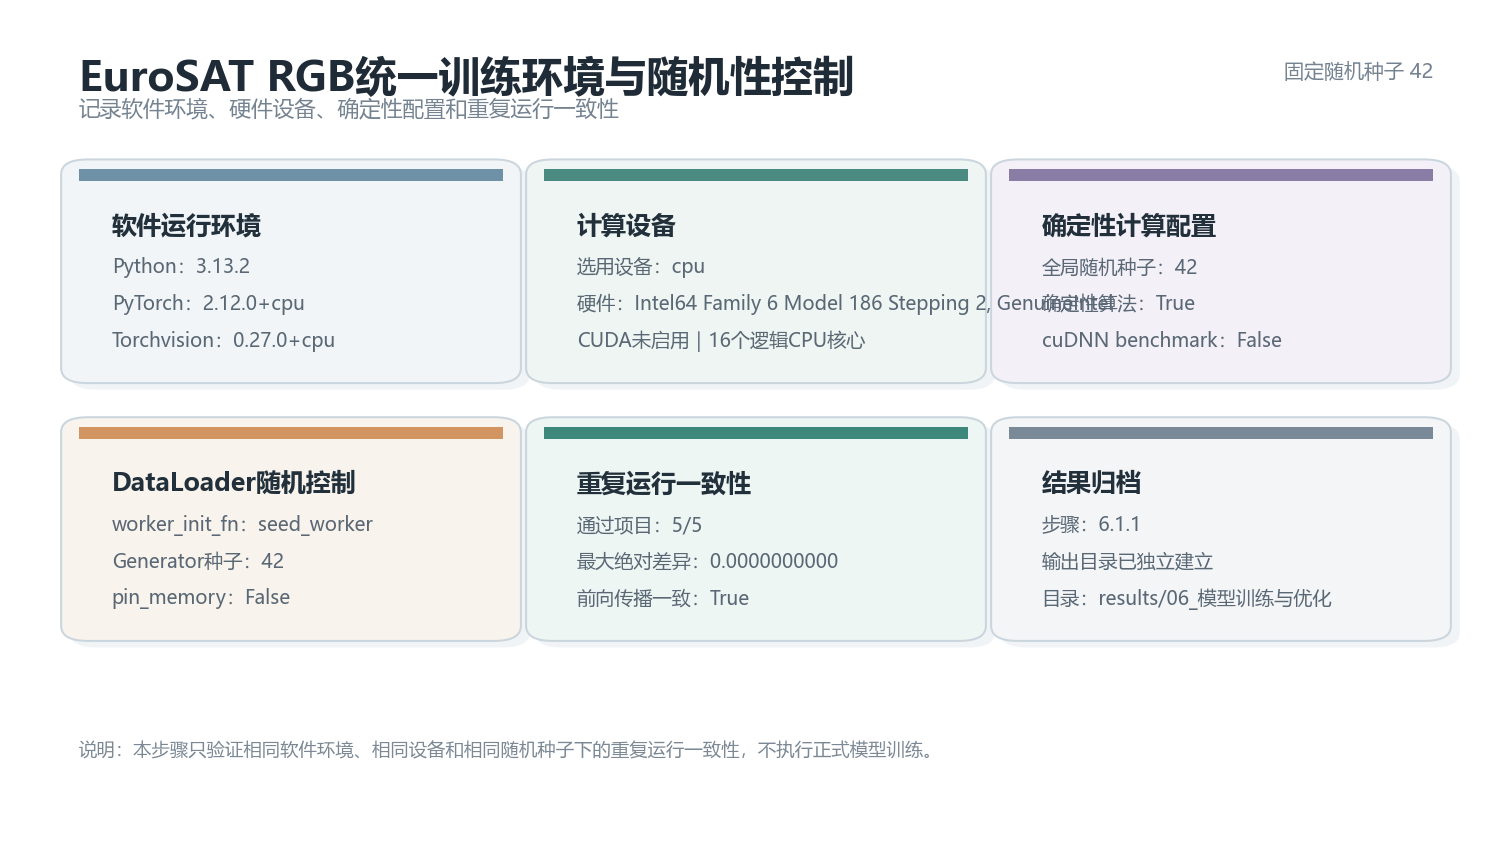

总览图已保存：05_训练环境与随机性控制总览.png


In [8]:
# ==========================================
# 6.1.1 训练环境与随机性控制总览图
# ==========================================

def draw_information_card(
    axis,
    x,
    y,
    width,
    height,
    title,
    content_lines,
    face_color,
    accent_color
):
    """
    在统一画布中绘制信息卡片。
    """

    shadow_patch = FancyBboxPatch(
        (
            x + 0.006,
            y - 0.008
        ),
        width,
        height,
        boxstyle=(
            "round,pad=0.012,"
            "rounding_size=0.018"
        ),
        linewidth=0,
        facecolor="#D9E1E7",
        alpha=0.35,
        transform=axis.transAxes,
        zorder=1
    )

    axis.add_patch(
        shadow_patch
    )

    card_patch = FancyBboxPatch(
        (
            x,
            y
        ),
        width,
        height,
        boxstyle=(
            "round,pad=0.012,"
            "rounding_size=0.018"
        ),
        linewidth=1.2,
        edgecolor="#CAD5DD",
        facecolor=face_color,
        transform=axis.transAxes,
        zorder=2
    )

    axis.add_patch(
        card_patch
    )

    accent_patch = Rectangle(
        (
            x,
            y + height - 0.014
        ),
        width,
        0.014,
        linewidth=0,
        facecolor=accent_color,
        transform=axis.transAxes,
        zorder=3
    )

    axis.add_patch(
        accent_patch
    )

    axis.text(
        x + 0.022,
        y + height - 0.052,
        title,
        fontsize=15,
        fontweight="bold",
        color="#22303C",
        va="top",
        transform=axis.transAxes,
        zorder=4
    )

    content_start_y = (
        y + height - 0.105
    )

    line_gap = 0.044

    for line_index, line_text in enumerate(
        content_lines
    ):

        axis.text(
            x + 0.022,
            content_start_y
            - line_index * line_gap,
            line_text,
            fontsize=11.5,
            color="#5A6875",
            va="top",
            transform=axis.transAxes,
            zorder=4
        )


python_version_text = (
    platform.python_version()
)

pytorch_version_text = (
    torch.__version__
)

torchvision_version_text = (
    torchvision.__version__
)

if cuda_available:

    compute_device_text = (
        torch.cuda.get_device_name(0)
    )

    cuda_status_text = (
        f"CUDA {cuda_build_version}"
    )

    memory_text = (
        f"{torch.cuda.get_device_properties(0).total_memory / (1024 ** 3):.2f} GB显存"
    )

else:

    compute_device_text = (
        platform.processor()
        or "CPU"
    )

    cuda_status_text = (
        "CUDA未启用"
    )

    memory_text = (
        f"{os.cpu_count()}个逻辑CPU核心"
    )


passed_check_count = int(
    reproducibility_check_df[
        "是否一致"
    ].sum()
)

total_check_count = len(
    reproducibility_check_df
)

maximum_recorded_difference = float(
    reproducibility_check_df[
        "最大绝对差异"
    ].max()
)


fig, ax = plt.subplots(
    figsize=(16, 9)
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.axis(
    "off"
)


# ------------------------------
# 标题区域
# ------------------------------
ax.text(
    0.045,
    0.945,
    "EuroSAT RGB统一训练环境与随机性控制",
    fontsize=25,
    fontweight="bold",
    color="#1F2B36",
    va="top",
    transform=ax.transAxes
)

ax.text(
    0.045,
    0.895,
    "记录软件环境、硬件设备、确定性配置和重复运行一致性",
    fontsize=13,
    color="#758391",
    va="top",
    transform=ax.transAxes
)

ax.text(
    0.955,
    0.94,
    f"固定随机种子 {GLOBAL_SEED}",
    fontsize=12,
    color="#758391",
    va="top",
    ha="right",
    transform=ax.transAxes
)


# ------------------------------
# 六张信息卡片
# ------------------------------
card_width = 0.285
card_height = 0.245

x_positions = [
    0.045,
    0.3575,
    0.67
]

y_positions = [
    0.565,
    0.255
]


draw_information_card(
    ax,
    x_positions[0],
    y_positions[0],
    card_width,
    card_height,
    "软件运行环境",
    [
        f"Python：{python_version_text}",
        f"PyTorch：{pytorch_version_text}",
        f"Torchvision：{torchvision_version_text}"
    ],
    "#F1F5F7",
    "#6F91A8"
)


draw_information_card(
    ax,
    x_positions[1],
    y_positions[0],
    card_width,
    card_height,
    "计算设备",
    [
        f"选用设备：{DEVICE}",
        f"硬件：{compute_device_text}",
        f"{cuda_status_text}｜{memory_text}"
    ],
    "#EEF5F2",
    "#4B8A80"
)


draw_information_card(
    ax,
    x_positions[2],
    y_positions[0],
    card_width,
    card_height,
    "确定性计算配置",
    [
        f"全局随机种子：{GLOBAL_SEED}",
        f"确定性算法：{deterministic_algorithms_enabled}",
        (
            "cuDNN benchmark："
            f"{cudnn_benchmark}"
        )
    ],
    "#F3F0F8",
    "#897DA5"
)


draw_information_card(
    ax,
    x_positions[0],
    y_positions[1],
    card_width,
    card_height,
    "DataLoader随机控制",
    [
        "worker_init_fn：seed_worker",
        f"Generator种子：{GLOBAL_SEED}",
        (
            f"pin_memory：{PIN_MEMORY}"
        )
    ],
    "#F8F3EC",
    "#D29562"
)


draw_information_card(
    ax,
    x_positions[1],
    y_positions[1],
    card_width,
    card_height,
    "重复运行一致性",
    [
        (
            "通过项目："
            f"{passed_check_count}/{total_check_count}"
        ),
        (
            "最大绝对差异："
            f"{maximum_recorded_difference:.10f}"
        ),
        (
            "前向传播一致："
            f"{forward_is_equal}"
        )
    ],
    "#EEF6F4",
    "#3D887B"
)


draw_information_card(
    ax,
    x_positions[2],
    y_positions[1],
    card_width,
    card_height,
    "结果归档",
    [
        "步骤：6.1.1",
        "输出目录已独立建立",
        (
            "目录：results/"
            "06_模型训练与优化"
        )
    ],
    "#F3F5F7",
    "#7A8997"
)


# ------------------------------
# 底部说明
# ------------------------------
ax.text(
    0.045,
    0.105,
    (
        "说明：本步骤只验证相同软件环境、"
        "相同设备和相同随机种子下的重复运行一致性，"
        "不执行正式模型训练。"
    ),
    fontsize=11,
    color="#7C8994",
    transform=ax.transAxes
)


overview_figure_path = (
    STEP_OUTPUT_DIR
    / "05_训练环境与随机性控制总览.png"
)

plt.savefig(
    overview_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


print(
    f"总览图已保存："
    f"{overview_figure_path.name}"
)

In [9]:
# ==========================================
# 6.1.1 统一配置保存、完整性检查与文件清单
# ==========================================

# ------------------------------
# 保存后续训练可复用的统一配置
# ------------------------------
unified_runtime_config = {
    "步骤编号": "6.1.1",
    "步骤名称": (
        "统一训练环境与随机性控制"
    ),
    "生成时间": datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    ),
    "项目根目录": str(
        PROJECT_ROOT
    ),
    "数据集目录": str(
        DATA_DIR
    ),
    "模型目录": str(
        MODELS_DIR
    ),
    "结果目录": str(
        STEP_OUTPUT_DIR
    ),
    "随机种子": GLOBAL_SEED,
    "确定性模式": (
        DETERMINISTIC_MODE
    ),
    "确定性警告模式": (
        DETERMINISTIC_WARN_ONLY
    ),
    "确定性算法已启用": (
        bool(
            deterministic_algorithms_enabled
        )
    ),
    "cuDNN_deterministic": (
        bool(
            cudnn_deterministic
        )
    ),
    "cuDNN_benchmark": (
        bool(
            cudnn_benchmark
        )
    ),
    "运行设备": str(
        DEVICE
    ),
    "CUDA可用": bool(
        cuda_available
    ),
    "CUDA设备数量": int(
        cuda_device_count
    ),
    "MPS可用": bool(
        mps_available
    ),
    "pin_memory": bool(
        PIN_MEMORY
    ),
    "non_blocking": bool(
        NON_BLOCKING
    ),
    "CUDA混合精度可用": bool(
        AMP_AVAILABLE
    ),
    "Python版本": (
        platform.python_version()
    ),
    "PyTorch版本": (
        torch.__version__
    ),
    "Torchvision版本": (
        torchvision.__version__
    ),
    "CUDA构建版本": (
        cuda_build_version
    ),
    "cuDNN版本": (
        str(cudnn_version)
    ),
    "DataLoader_worker_init_fn": (
        "seed_worker"
    ),
    "DataLoader_generator_seed": (
        GLOBAL_SEED
    ),
    "重复运行检查通过": bool(
        all_reproducibility_checks_passed
    )
}


unified_config_path = (
    STEP_OUTPUT_DIR
    / "07_统一训练环境配置.json"
)

with open(
    unified_config_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        unified_runtime_config,
        file,
        ensure_ascii=False,
        indent=4
    )


# ------------------------------
# 完整性检查
# ------------------------------
required_output_files = [
    STEP_OUTPUT_DIR
    / "01_随机性控制配置.json",

    STEP_OUTPUT_DIR
    / "02_运行环境信息.csv",

    STEP_OUTPUT_DIR
    / "03_设备与加速器信息.csv",

    STEP_OUTPUT_DIR
    / "04_随机性复现检查.csv",

    STEP_OUTPUT_DIR
    / "05_训练环境与随机性控制总览.png",

    STEP_OUTPUT_DIR
    / "07_统一训练环境配置.json"
]


if cuda_available:

    cudnn_configuration_correct = (
        bool(
            torch.backends.cudnn.deterministic
        )
        and not bool(
            torch.backends.cudnn.benchmark
        )
    )

else:

    cudnn_configuration_correct = True


integrity_check_records = [
    {
        "检查项目": "项目根目录定位",
        "检查结果": str(
            PROJECT_ROOT
        ),
        "是否通过": PROJECT_ROOT.exists()
    },
    {
        "检查项目": "EuroSAT数据目录",
        "检查结果": str(
            DATA_DIR
        ),
        "是否通过": DATA_DIR.exists()
    },
    {
        "检查项目": "本步骤输出目录",
        "检查结果": str(
            STEP_OUTPUT_DIR
        ),
        "是否通过": (
            STEP_OUTPUT_DIR.exists()
        )
    },
    {
        "检查项目": "全局随机种子",
        "检查结果": (
            f"固定为{GLOBAL_SEED}"
        ),
        "是否通过": (
            isinstance(
                GLOBAL_SEED,
                int
            )
        )
    },
    {
        "检查项目": "确定性算法",
        "检查结果": (
            deterministic_algorithms_enabled
        ),
        "是否通过": bool(
            deterministic_algorithms_enabled
        )
    },
    {
        "检查项目": "cuDNN确定性配置",
        "检查结果": (
            "配置正确"
            if cudnn_configuration_correct
            else "配置异常"
        ),
        "是否通过": (
            cudnn_configuration_correct
        )
    },
    {
        "检查项目": "计算设备选择",
        "检查结果": str(
            DEVICE
        ),
        "是否通过": (
            DEVICE.type
            in {
                "cpu",
                "cuda",
                "mps"
            }
        )
    },
    {
        "检查项目": "随机序列复现",
        "检查结果": (
            f"{passed_check_count}/"
            f"{total_check_count}项通过"
        ),
        "是否通过": (
            all_reproducibility_checks_passed
        )
    },
    {
        "检查项目": "必要输出文件",
        "检查结果": (
            f"{sum(path.exists() for path in required_output_files)}"
            f"/{len(required_output_files)}个文件已生成"
        ),
        "是否通过": all(
            path.exists()
            for path in required_output_files
        )
    }
]


integrity_check_df = pd.DataFrame(
    integrity_check_records
)


integrity_check_path = (
    STEP_OUTPUT_DIR
    / "06_训练环境完整性检查.csv"
)

integrity_check_df.to_csv(
    integrity_check_path,
    index=False,
    encoding="utf-8-sig"
)


all_integrity_checks_passed = bool(
    integrity_check_df[
        "是否通过"
    ].all()
)


print(
    "训练环境与随机性控制完整性检查："
)

display(
    integrity_check_df
)


assert all_integrity_checks_passed, (
    "训练环境完整性检查未全部通过，"
    "请先根据失败项目检查环境配置。"
)


# ------------------------------
# 生成最终输出文件清单
# ------------------------------
manifest_path = (
    STEP_OUTPUT_DIR
    / "08_输出文件清单.csv"
)

# 先创建占位文件，使清单中包含自身
manifest_path.touch(
    exist_ok=True
)


output_file_records = []

for output_path in sorted(
    STEP_OUTPUT_DIR.iterdir()
):

    if not output_path.is_file():
        continue

    file_size_kb = (
        output_path.stat().st_size
        / 1024
    )

    output_file_records.append({
        "文件名称": output_path.name,
        "文件类型": (
            output_path.suffix.lower()
        ),
        "文件大小_KB": round(
            file_size_kb,
            2
        ),
        "相对路径": str(
            output_path.relative_to(
                PROJECT_ROOT
            )
        )
    })


output_manifest_df = pd.DataFrame(
    output_file_records
)

output_manifest_df.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\n6.1.1 统一训练环境与随机性控制执行完成。"
)

print(
    f"所有结果均已保存至：\n"
    f"{STEP_OUTPUT_DIR}"
)

print(
    "\n输出文件清单："
)

display(
    output_manifest_df
)

训练环境与随机性控制完整性检查：


,检查项目,检查结果,是否通过
0,项目根目录定位,d:\qy\junior\深度学习\课设,True
1,EuroSAT数据目录,d:\qy\junior\深度学习\课设\EuroSAT_RGB,True
2,本步骤输出目录,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制,True
3,全局随机种子,固定为42,True
4,确定性算法,True,True
5,cuDNN确定性配置,配置正确,True
6,计算设备选择,cpu,True
7,随机序列复现,5/5项通过,True
8,必要输出文件,6/6个文件已生成,True



6.1.1 统一训练环境与随机性控制执行完成。
所有结果均已保存至：
d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制

输出文件清单：


,文件名称,文件类型,文件大小_KB,相对路径
0,01_随机性控制配置.json,.json,0.49,results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\01_随机性控制配置.json
1,02_运行环境信息.csv,.csv,0.82,results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\02_运行环境信息.csv
2,03_设备与加速器信息.csv,.csv,0.40,results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\03_设备与加速器信息.csv
3,04_随机性复现检查.csv,.csv,0.34,results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\04_随机性复现检查.csv
4,05_训练环境与随机性控制总览.png,.png,468.67,results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\05_训练环境与随机性控制总览.png
5,06_训练环境完整性检查.csv,.csv,0.52,results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\06_训练环境完整性检查.csv
6,07_统一训练环境配置.json,.json,1.18,results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\07_统一训练环境配置.json
7,08_输出文件清单.csv,.csv,0.00,results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\08_输出文件清单.csv


#### 6.1.1 统一训练环境与随机性控制小结

本节完成了项目路径定位、独立结果目录建立、软件版本记录、计算设备检测、随机种子固定、确定性算法配置以及重复运行一致性验证。项目根目录、EuroSAT RGB 数据目录、模型目录、Notebook 目录和结果目录均能够被正确识别，本步骤生成的环境信息、设备信息、随机性配置、复现检查结果、可视化总览图和统一配置文件均已保存至独立结果目录。

完整性检查中的所有项目均通过。全局随机种子固定为 42，确定性算法处于启用状态，随机序列与小型卷积网络前向传播的 5 项复现检查全部通过，最大绝对差异均为 0，说明当前实验环境能够满足后续模型对照训练所需的基本可复现性要求。

当前实验设备为 CPU，未启用 CUDA、cuDNN 和混合精度训练，因此后续模型训练将主要受到 CPU 计算效率限制。但这一情况不会影响训练流程和评价方法的正确性，只会增加训练所需时间。后续 BaselineCNN 与 ResNet18Transfer 应继续复用本节保存的随机种子、DataLoader 生成器、设备对象和确定性配置，从而保证两个候选模型在统一实验条件下进行训练与比较。

综上，6.1.1 的训练环境与随机性控制配置正确，结果完整，可以进入下一阶段的损失函数、评价指标和统一训练组件设计。
